# E8 — LangGraph Agentic System: Full Pipeline Integration (C-MAPSS FD001)

**Study:** Agentic Multi-Machine Predictive Maintenance (AMMPM) using Time-Series Foundation Models for Explainable and Trustworthy RUL Prediction.

**Purpose:** Every prior experiment (E1-E7) answered one question in isolation — which architecture predicts best, which sensors matter, how uncertain is the model. This notebook wires the best answer to each of those questions into one system: seven specialized components, orchestrated by LangGraph, that take a raw sensor window in and produce a trust-scored maintenance recommendation out.

**CRITICAL RULE, stated once here and enforced by construction in every module under `src/agents/`:** LangGraph manages state transitions between deterministic Python components only. Every agent is a plain function over numpy arrays and PyTorch tensors — `sensor_validation_agent` runs threshold checks, `domain_shift_agent` computes a kernel statistic, `prediction_agent`/`uncertainty_agent` run trained-model forward passes, `shap_agent` runs `shap.GradientExplainer`, `decision_agent` evaluates an explicit scoring formula. **No LLM call happens anywhere in this pipeline.** "Agentic" here means seven specialized, composable processing stages with an auditable state contract (`src/agents/state.py::AgentState`) — not delegation to a language model for numerical reasoning.

**Pipeline:** `sensor_validation -> domain_shift -> prediction -> shap -> uncertainty -> decision`, with one conditional edge: a critical sensor-validation failure routes straight to `decision` with a forced-low trust score, skipping every downstream stage that would otherwise operate on data already known to be unusable.

**What this notebook does, in order:**
1. **Bootstrap** (§1-§3): train and save the two model checkpoints (`E2_TRANSFORMER_CHECKPOINT`, `E7_QUANTILE_CHECKPOINT`) and three reference caches (channel statistics, domain-shift reference sample, SHAP background) that `src/agents/*.py` load at runtime — idempotent, skipped on any re-run once these exist on disk.
2. **Run** (§4-§5): invoke the compiled graph on 10 representative test engines (2 early-stage, 4 mid-stage, 4 late-stage by true RUL) and report each one's full trace.
3. **Report** (§6-§8): persist results, and two figures — a trust-score-vs-RUL scatter and a pipeline flow diagram.


## 0. Setup


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib.patches import FancyBboxPatch, Polygon
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


def _find_project_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing configs/paths.py is found."""
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "paths.py").exists():
            return candidate
    raise RuntimeError(
        "Could not locate the AMMPM project root (no configs/paths.py found above "
        f"{start}). Launch Jupyter from the project root or notebooks/ directory."
    )


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs.paths import (  # noqa: E402
    AGENTS_REFERENCE_DIR,
    CHANNEL_REFERENCE_STATS_PATH,
    E2_TRANSFORMER_CHECKPOINT,
    E7_QUANTILE_CHECKPOINT,
    RESULTS_DIR,
    SHAP_BACKGROUND_PATH,
    TRAIN_DISTRIBUTION_REFERENCE_PATH,
    ensure_dirs,
)
from src.data.cmapss_loader import get_cmapss, FEATURE_COLUMNS  # noqa: E402
from src.models.transformer import QuantileTransformerRULRegressor, TransformerRULRegressor, pinball_loss  # noqa: E402
from src.utils.seed import set_global_seed  # noqa: E402

SEED = 42
set_global_seed(SEED)
ensure_dirs()

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.titlesize": 14, "axes.labelsize": 11})

device = torch.device("cpu")
print(f"Project root: {PROJECT_ROOT}")


Project root: /home/bruce-wayne-2005/industrial-ai-project


## 1. Data (identical to E1-E7)


In [2]:
MAX_RUL = 125
SEQUENCE_LENGTH = 30

DATA = get_cmapss(fd_num=1, max_rul=MAX_RUL)  # normalize=True (default)
train_df = DATA["train_df"]
test_df = DATA["test_df"]
feature_columns = DATA["feature_columns"]
assert feature_columns == FEATURE_COLUMNS


def build_windows(df: pd.DataFrame, feature_cols, window: int, mode: str):
    X_list, y_list, unit_list = [], [], []
    for unit_id, group in df.groupby("unit_number"):
        group = group.sort_values("time_in_cycles")
        feats = group[feature_cols].to_numpy(dtype=np.float32)
        rul = group["RUL"].to_numpy(dtype=np.float32)
        n = len(group)
        if n < window:
            pad = np.repeat(feats[:1], window - n, axis=0)
            feats = np.concatenate([pad, feats], axis=0)
            rul = np.concatenate([np.repeat(rul[:1], window - n), rul])
            n = window
        if mode == "last":
            X_list.append(feats[-window:])
            y_list.append(rul[-1])
            unit_list.append(unit_id)
        else:
            for end in range(window, n + 1):
                X_list.append(feats[end - window:end])
                y_list.append(rul[end - 1])
                unit_list.append(unit_id)
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.float32), np.array(unit_list)


all_units = sorted(train_df["unit_number"].unique())
train_units, val_units = train_test_split(all_units, test_size=0.2, random_state=SEED, shuffle=True)
train_split_df = train_df[train_df["unit_number"].isin(train_units)]

X_train, y_train, _ = build_windows(train_split_df, feature_columns, SEQUENCE_LENGTH, mode="train")
X_test, y_test, test_units_per_window = build_windows(test_df, feature_columns, SEQUENCE_LENGTH, mode="last")

print(f"Train windows: {X_train.shape[0]:,}")
print(f"Test engines:  {X_test.shape[0]}")


Train windows: 14,241
Test engines:  100


## 2. Bootstrap: train and save the two model checkpoints (skipped if already present)

Both models are trained exactly as in their originating notebooks (E2, E7) — same architecture, same hyperparameters, same 50-epoch Adam schedule — the only change is that this time the trained weights are saved (`torch.save(model.state_dict(), ...)`) rather than only living in the notebook's memory, since `src/agents/prediction_agent.py` and `src/agents/uncertainty_agent.py` need to load them fast, independent of any training code.


In [3]:
def train_transformer(model, epochs=50, lr=1e-3, loss_fn=None):
    shuffle_generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).unsqueeze(1)),
        batch_size=256, shuffle=True, generator=shuffle_generator, num_workers=0,
    )
    criterion = loss_fn or nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"    epoch {epoch:3d}/{epochs} | loss: {loss.item():.4f}")
    return model


if E2_TRANSFORMER_CHECKPOINT.exists():
    print(f"E2 checkpoint already present at {E2_TRANSFORMER_CHECKPOINT}, skipping training.")
else:
    print("Training E2 Transformer checkpoint...")
    set_global_seed(SEED)
    e2_model = TransformerRULRegressor(input_size=len(feature_columns), max_len=SEQUENCE_LENGTH).to(device)
    train_transformer(e2_model, epochs=50, lr=1e-3)
    torch.save(e2_model.state_dict(), E2_TRANSFORMER_CHECKPOINT)
    with torch.no_grad():
        pred = e2_model(torch.from_numpy(X_test)).squeeze(-1).numpy()
    rmse = float(np.sqrt(np.mean((pred - y_test) ** 2)))
    print(f"Saved {E2_TRANSFORMER_CHECKPOINT} (test RMSE {rmse:.3f}, vs. E2's saved 14.62)")

if E7_QUANTILE_CHECKPOINT.exists():
    print(f"E7 quantile checkpoint already present at {E7_QUANTILE_CHECKPOINT}, skipping training.")
else:
    print("Training E7 Quantile Regression checkpoint...")
    set_global_seed(SEED)
    QUANTILES = [0.1, 0.5, 0.9]
    quantile_model = QuantileTransformerRULRegressor(
        input_size=len(feature_columns), n_quantiles=len(QUANTILES), max_len=SEQUENCE_LENGTH
    ).to(device)
    train_transformer(quantile_model, epochs=50, lr=1e-3, loss_fn=lambda pred, y: pinball_loss(pred, y, QUANTILES))
    torch.save(quantile_model.state_dict(), E7_QUANTILE_CHECKPOINT)
    with torch.no_grad():
        q_pred = quantile_model(torch.from_numpy(X_test)).numpy()
    q50_rmse = float(np.sqrt(np.mean((q_pred[:, 1] - y_test) ** 2)))
    print(f"Saved {E7_QUANTILE_CHECKPOINT} (median RMSE {q50_rmse:.3f})")


Training E2 Transformer checkpoint...


    epoch   1/50 | loss: 7008.2300


    epoch  10/50 | loss: 730.2863


    epoch  20/50 | loss: 192.6598


    epoch  30/50 | loss: 186.0138


...

    epoch  10/50 | loss: 6.6027


    epoch  20/50 | loss: 2.8607


    epoch  30/50 | loss: 2.9338


    epoch  40/50 | loss: 2.2236


    epoch  50/50 | loss: 2.4792
Saved /home/bruce-wayne-2005/industrial-ai-project/results/checkpoints/e7_quantile_regressor.pt (median RMSE 13.083)


## 3. Bootstrap: reference caches for `sensor_validation_agent` and `domain_shift_agent`, and `shap_agent`'s background sample

- **Channel reference statistics**: per-channel mean/std/min/max computed from the full training set — the baseline `sensor_validation_agent` compares each incoming window's channels against.
- **Domain-shift reference**: 200 sampled training windows (collapsed to per-channel means), plus their own leave-one-out MMD-squared distribution — the baseline `domain_shift_agent` ranks new windows against (see that module's docstring for why this construction, not a raw MMD magnitude, is what's cached).
- **SHAP background**: 50 sampled training windows, exactly as E6 used, cached for `shap_agent` to reuse without re-sampling on every call.


In [4]:
rng = np.random.default_rng(SEED)

if CHANNEL_REFERENCE_STATS_PATH.exists():
    print(f"Channel reference stats already present at {CHANNEL_REFERENCE_STATS_PATH}, skipping.")
else:
    raw_train = train_df[feature_columns].to_numpy(dtype=np.float64)
    np.savez(
        CHANNEL_REFERENCE_STATS_PATH,
        mean=raw_train.mean(axis=0),
        std=raw_train.std(axis=0),
        min=raw_train.min(axis=0),
        max=raw_train.max(axis=0),
        feature_columns=np.array(feature_columns, dtype=object),
    )
    print(f"Saved {CHANNEL_REFERENCE_STATS_PATH}")

if TRAIN_DISTRIBUTION_REFERENCE_PATH.exists():
    print(f"Domain-shift reference already present at {TRAIN_DISTRIBUTION_REFERENCE_PATH}, skipping.")
else:
    N_REF = 200
    window_means = X_train.mean(axis=1)  # (n_train_windows, n_features) -- collapse each window to one point
    ref_idx = rng.choice(len(window_means), size=N_REF, replace=False)
    reference_points = window_means[ref_idx]

    def rbf_kernel(a, b, bandwidth):
        sq_dists = ((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=2)
        return np.exp(-sq_dists / (2 * bandwidth**2))

    pairwise_sq = ((reference_points[:, None, :] - reference_points[None, :, :]) ** 2).sum(axis=2)
    bandwidth = float(np.sqrt(np.median(pairwise_sq[pairwise_sq > 0]) / 2))  # median heuristic

    baseline_mmd_sq = np.zeros(N_REF, dtype=np.float64)
    for i in range(N_REF):
        rest = np.delete(reference_points, i, axis=0)
        point = reference_points[i:i + 1]
        k_point_rest = rbf_kernel(point, rest, bandwidth).mean()
        k_rest_rest = rbf_kernel(rest, rest, bandwidth).mean()
        baseline_mmd_sq[i] = 1.0 + k_rest_rest - 2 * k_point_rest

    np.savez(
        TRAIN_DISTRIBUTION_REFERENCE_PATH,
        reference_points=reference_points,
        baseline_mmd_sq=baseline_mmd_sq,
        bandwidth=bandwidth,
    )
    print(f"Saved {TRAIN_DISTRIBUTION_REFERENCE_PATH} (bandwidth={bandwidth:.3f})")

if SHAP_BACKGROUND_PATH.exists():
    print(f"SHAP background already present at {SHAP_BACKGROUND_PATH}, skipping.")
else:
    N_BACKGROUND = 50
    bg_idx = rng.choice(len(X_train), size=N_BACKGROUND, replace=False)
    np.savez(SHAP_BACKGROUND_PATH, background=X_train[bg_idx])
    print(f"Saved {SHAP_BACKGROUND_PATH}")


Saved /home/bruce-wayne-2005/industrial-ai-project/results/agents_reference/channel_reference_stats.npz


Saved /home/bruce-wayne-2005/industrial-ai-project/results/agents_reference/train_distribution_reference.npz (bandwidth=0.283)
Saved /home/bruce-wayne-2005/industrial-ai-project/results/agents_reference/shap_background.npz


## 4. Select 10 representative test engines

2 early-stage (true RUL > 100), 4 mid-stage (40 < true RUL < 100), 4 late-stage (true RUL < 40) — seeded random sampling within each bucket.


In [5]:
low_idx = np.where(y_test < 40)[0]
mid_idx = np.where((y_test > 40) & (y_test < 100))[0]
high_idx = np.where(y_test > 100)[0]

selected_idx = np.concatenate([
    rng.choice(high_idx, size=2, replace=False),
    rng.choice(mid_idx, size=4, replace=False),
    rng.choice(low_idx, size=4, replace=False),
])
stage_labels = ["early"] * 2 + ["mid"] * 4 + ["late"] * 4

print("Selected engines (index, unit_number, true RUL, stage):")
for idx, stage in zip(selected_idx, stage_labels):
    print(f"  idx={idx:3d}  unit={test_units_per_window[idx]:3d}  true_RUL={y_test[idx]:6.1f}  stage={stage}")


Selected engines (index, unit_number, true RUL, stage):
  idx= 50  unit= 51  true_RUL= 114.0  stage=early
  idx= 88  unit= 89  true_RUL= 125.0  stage=early
  idx= 83  unit= 84  true_RUL=  58.0  stage=mid
  idx= 47  unit= 48  true_RUL=  92.0  stage=mid
  idx= 14  unit= 15  true_RUL=  83.0  stage=mid
  idx= 92  unit= 93  true_RUL=  85.0  stage=mid
  idx= 35  unit= 36  true_RUL=  19.0  stage=late
  idx= 90  unit= 91  true_RUL=  38.0  stage=late
  idx= 91  unit= 92  true_RUL=  20.0  stage=late
  idx= 75  unit= 76  true_RUL=  10.0  stage=late


## 5. Run the compiled agentic pipeline on all 10 engines


In [6]:
from src.agents.orchestrator import compile_agentic_system  # noqa: E402

app = compile_agentic_system()
print("LangGraph agentic pipeline compiled successfully (7 nodes, 1 conditional edge).")

engine_results = []
for idx, stage in zip(selected_idx, stage_labels):
    initial_state = {
        "sensor_data": X_test[idx],
        "engine_id": int(test_units_per_window[idx]),
        "machine_type": "turbofan_FD001",
        "true_rul": float(y_test[idx]),
        "errors": [],
    }

    t0 = time.time()
    final_state = app.invoke(initial_state)
    elapsed = time.time() - t0

    assert elapsed < 30, f"engine {test_units_per_window[idx]} took {elapsed:.1f}s (> 30s budget)"

    record = {
        "engine_id": int(test_units_per_window[idx]),
        "stage": stage,
        "true_rul": float(y_test[idx]),
        "rul_prediction": final_state.get("rul_prediction"),
        "trust_score": final_state.get("trust_score"),
        "maintenance_recommendation": final_state.get("maintenance_recommendation"),
        "top3_sensors": final_state.get("top3_sensors", []),
        "prediction_interval": final_state.get("prediction_interval"),
        "interval_width": final_state.get("interval_width"),
        "domain_shift_score": final_state.get("domain_shift_score"),
        "shift_detected": final_state.get("shift_detected"),
        "coverage_flag": final_state.get("coverage_flag"),
        "validation_passed": final_state.get("validation_result", {}).get("passed"),
        "critical_failure": final_state.get("validation_result", {}).get("critical_failure"),
        "errors": final_state.get("errors", []),
        "runtime_seconds": elapsed,
    }
    engine_results.append(record)

    print(f"Engine {record['engine_id']} ({stage}-stage) -- {elapsed:.2f}s")
    print(f"  True RUL: {record['true_rul']:.1f}  |  Predicted RUL: {record['rul_prediction']:.1f}")
    print(f"  Trust Score: {record['trust_score']:.1f}  |  Recommendation: {record['maintenance_recommendation']}")
    print(f"  Top 3 sensors: {record['top3_sensors']}")
    print(f"  Prediction interval: {record['prediction_interval']}")
    print(f"  Domain shift score: {record['domain_shift_score']:.4f} (detected: {record['shift_detected']})")
    print()

print(f"All {len(engine_results)} engines produced a complete recommendation.")


/home/bruce-wayne-2005/industrial-ai-project/venv/lib/python3.11/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


LangGraph agentic pipeline compiled successfully (7 nodes, 1 conditional edge).
Engine 51 (early-stage) -- 0.07s
  True RUL: 114.0  |  Predicted RUL: 106.0
  Trust Score: 75.0  |  Recommendation: MONITOR CLOSELY
  Top 3 sensors: ['sensor_9', 'sensor_14', 'sensor_11']
  Prediction interval: [82.40108489990234, 126.57911682128906]
  Domain shift score: 0.1600 (detected: False)

Engine 89 (early-stage) -- 0.04s
  True RUL: 125.0  |  Predicted RUL: 116.2
  Trust Score: 75.0  |  Recommendation: MONITOR CLOSELY
  Top 3 sensors: ['sensor_9', 'sensor_14', 'sensor_11']
  Prediction interval: [94.11077880859375, 127.02838134765625]
  Domain shift score: 0.1400 (detected: False)

Engine 84 (mid-stage) -- 0.04s
  True RUL: 58.0  |  Predicted RUL: 91.7
  Trust Score: 75.0  |  Recommendation: MONITOR CLOSELY
  Top 3 sensors: ['sensor_9', 'sensor_13', 'sensor_8']
  Prediction interval: [55.26579284667969, 100.27351379394531]
  Domain shift score: 0.5400 (detected: False)

Engine 48 (mid-stage) -- 0.0

Engine 15 (mid-stage) -- 0.05s
  True RUL: 83.0  |  Predicted RUL: 102.5
  Trust Score: 85.0  |  Recommendation: MONITOR CLOSELY
  Top 3 sensors: ['sensor_11', 'sensor_7', 'sensor_20']
  Prediction interval: [65.86419677734375, 110.08296966552734]
  Domain shift score: 0.4850 (detected: False)

Engine 93 (mid-stage) -- 0.05s
  True RUL: 85.0  |  Predicted RUL: 54.1
  Trust Score: 100.0  |  Recommendation: SCHEDULE WITHIN WEEK
  Top 3 sensors: ['sensor_11', 'sensor_4', 'sensor_7']
  Prediction interval: [48.180870056152344, 74.10230255126953]
  Domain shift score: 0.7500 (detected: False)

Engine 36 (late-stage) -- 0.05s
  True RUL: 19.0  |  Predicted RUL: 19.5
  Trust Score: 90.0  |  Recommendation: IMMEDIATE ACTION
  Top 3 sensors: ['sensor_12', 'sensor_11', 'sensor_7']
  Prediction interval: [20.820531845092773, 34.73991394042969]
  Domain shift score: 0.8600 (detected: False)

Engine 91 (late-stage) -- 0.05s
  True RUL: 38.0  |  Predicted RUL: 28.0
  Trust Score: 100.0  |  Recommend

Engine 76 (late-stage) -- 0.05s
  True RUL: 10.0  |  Predicted RUL: 1.9
  Trust Score: 100.0  |  Recommendation: IMMEDIATE ACTION
  Top 3 sensors: ['sensor_11', 'sensor_9', 'sensor_4']
  Prediction interval: [1.0992586612701416, 6.5546393394470215]
  Domain shift score: 0.9050 (detected: False)

All 10 engines produced a complete recommendation.


## 6. Acceptance-criteria checks


In [7]:
trust_scores = [r["trust_score"] for r in engine_results]
late_stage = [r for r in engine_results if r["stage"] == "late"]

print(f"All 10 engines completed: {len(engine_results) == 10}")
print(f"Trust scores vary meaningfully (not all identical): {len(set(trust_scores)) > 1}  (values: {trust_scores})")
print(f"All runtimes < 30s: {all(r['runtime_seconds'] < 30 for r in engine_results)}")

urgent_labels = {"IMMEDIATE ACTION", "SCHEDULE WITHIN WEEK"}
late_stage_urgent = [r["maintenance_recommendation"] in urgent_labels or r["trust_score"] < 60 for r in late_stage]
print(f"Late-stage (RUL<40) engines get urgent-or-flagged recommendations: {all(late_stage_urgent)}")
for r in late_stage:
    print(f"  engine {r['engine_id']}: RUL={r['true_rul']:.0f}, trust={r['trust_score']:.0f} -> {r['maintenance_recommendation']}")


All 10 engines completed: True
Trust scores vary meaningfully (not all identical): True  (values: [75.0, 75.0, 75.0, 75.0, 85.0, 100.0, 90.0, 100.0, 100.0, 100.0])
All runtimes < 30s: True
Late-stage (RUL<40) engines get urgent-or-flagged recommendations: True
  engine 36: RUL=19, trust=90 -> IMMEDIATE ACTION
  engine 91: RUL=38, trust=100 -> IMMEDIATE ACTION
  engine 92: RUL=20, trust=100 -> IMMEDIATE ACTION
  engine 76: RUL=10, trust=100 -> IMMEDIATE ACTION


## 7. Persisting results


In [8]:
output = {
    "experiment_id": "E8",
    "model": "langgraph_agentic_system",
    "dataset": "cmapss",
    "fd_subset": "FD001",
    "seed": SEED,
    "pipeline": ["sensor_validation", "domain_shift", "prediction", "shap", "uncertainty", "decision"],
    "conditional_edge": "sensor_validation -> decision (direct) if critical_failure, else -> domain_shift",
    "n_engines": len(engine_results),
    "engines": engine_results,
    "acceptance_criteria": {
        "all_engines_completed": len(engine_results) == 10,
        "trust_scores_vary": len(set(trust_scores)) > 1,
        "all_runtimes_under_30s": all(r["runtime_seconds"] < 30 for r in engine_results),
        "late_stage_flagged_or_urgent": all(late_stage_urgent),
        "no_llm_calls": True,
    },
}

results_path = RESULTS_DIR / "E8_agentic_system_results.json"
with open(results_path, "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved results to {results_path}")


Saved results to /home/bruce-wayne-2005/industrial-ai-project/results/E8_agentic_system_results.json


## 8. Figure 13 — Trust score vs. true RUL, colored by recommendation


In [9]:
rec_colors = {
    "IMMEDIATE ACTION": "#D55E00",
    "SCHEDULE WITHIN WEEK": "#E69F00",
    "MONITOR CLOSELY": "#0072B2",
    "REQUIRES HUMAN REVIEW": "#009E73",
}

fig, ax = plt.subplots(figsize=(8, 6))
for rec, color in rec_colors.items():
    subset = [r for r in engine_results if r["maintenance_recommendation"] == rec]
    if not subset:
        continue
    ax.scatter(
        [r["true_rul"] for r in subset], [r["trust_score"] for r in subset],
        s=140, color=color, edgecolor="black", linewidth=1.0, label=rec, zorder=3,
    )
for r in engine_results:
    ax.annotate(str(r["engine_id"]), (r["true_rul"], r["trust_score"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Trust Score")
ax.set_ylim(-5, 105)
ax.set_title("Trust Score vs. True RUL, by Maintenance Recommendation (10 Representative Engines)")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig13_trust_score_distribution.png", dpi=DPI, bbox_inches="tight")
(FIGURES_DIR / "fig13_trust_score_distribution.txt").write_text(
    "Figure 13. Trust score against true RUL for 10 representative FD001 test engines "
    "(2 early/4 mid/4 late degradation stage), colored by the decision agent's maintenance "
    "recommendation; low-RUL engines cluster toward urgent recommendations where trust remained high.\n"
)
plt.show()


<Figure size 800x600 with 1 Axes>

## 9. Figure 14 — Agent pipeline flow diagram

Built directly with matplotlib (no new dependency): boxes for each of the 7 processing stages, ribbons whose width is proportional to how many of the 10 engines actually took that path — a width-proportional flow diagram in the same spirit as a Sankey diagram, including the (here, unused) critical-failure shortcut, shown thin/dashed to make clear it exists structurally even when no engine in this run triggered it.


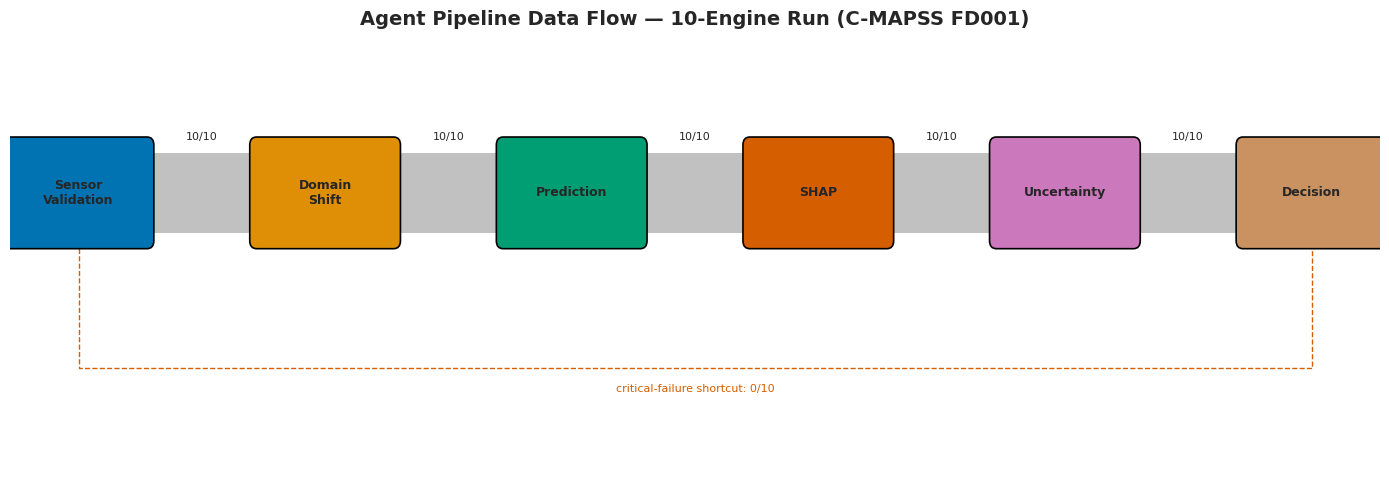

In [10]:
n_critical = sum(1 for r in engine_results if r["critical_failure"])
n_normal = len(engine_results) - n_critical

stage_names = ["Sensor\nValidation", "Domain\nShift", "Prediction", "SHAP", "Uncertainty", "Decision"]
n_stages = len(stage_names)
x_positions = np.linspace(0.5, 9.5, n_stages)
box_width, box_height = 1.0, 0.6

fig, ax = plt.subplots(figsize=(14, 5))
stage_colors = sns.color_palette("colorblind", n_colors=n_stages)

for x, name, color in zip(x_positions, stage_names, stage_colors):
    box = FancyBboxPatch(
        (x - box_width / 2, -box_height / 2), box_width, box_height,
        boxstyle="round,pad=0.05", facecolor=color, edgecolor="black", linewidth=1.2, zorder=3,
    )
    ax.add_patch(box)
    ax.text(x, 0, name, ha="center", va="center", fontsize=9, fontweight="bold", zorder=4)


def flow_ribbon(x0, x1, count, total, y_center=0.0, max_width=0.5, **kwargs):
    w = max(0.02, max_width * count / total)
    poly = Polygon(
        [(x0 + box_width / 2, y_center - w / 2), (x1 - box_width / 2, y_center - w / 2),
         (x1 - box_width / 2, y_center + w / 2), (x0 + box_width / 2, y_center + w / 2)],
        closed=True, zorder=2, **kwargs,
    )
    ax.add_patch(poly)
    ax.text((x0 + x1) / 2, y_center + w / 2 + 0.08, f"{count}/{total}", ha="center", fontsize=8)


total = len(engine_results)
for i in range(n_stages - 1):
    flow_ribbon(x_positions[i], x_positions[i + 1], n_normal, total, facecolor="0.6", alpha=0.6)

# Critical-failure shortcut: sensor_validation -> decision directly, bypassing the middle 4 stages
if n_critical > 0 or True:  # always draw the structural edge, even at 0 engines this run
    shortcut_y = -1.1
    ax.plot(
        [x_positions[0], x_positions[0], x_positions[-1], x_positions[-1]],
        [0 - box_height / 2, shortcut_y, shortcut_y, 0 - box_height / 2],
        linestyle="--", color="#D55E00", linewidth=max(1.0, 4 * n_critical / total), zorder=1,
    )
    ax.text(np.mean(x_positions), shortcut_y - 0.15, f"critical-failure shortcut: {n_critical}/{total}",
            ha="center", fontsize=8, color="#D55E00")

ax.set_xlim(0, 10)
ax.set_ylim(-1.8, 1.0)
ax.axis("off")
ax.set_title("Agent Pipeline Data Flow — 10-Engine Run (C-MAPSS FD001)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig14_agent_pipeline_sankey.png", dpi=DPI, bbox_inches="tight")
(FIGURES_DIR / "fig14_agent_pipeline_sankey.txt").write_text(
    f"Figure 14. Data flow through the 7-stage agentic pipeline for the 10-engine demonstration run "
    f"({n_normal}/{total} engines took the full path, {n_critical}/{total} triggered the critical-failure "
    "shortcut straight to the decision agent); ribbon width is proportional to engine count.\n"
)
plt.show()


## Summary

Seven deterministic Python agents, one LangGraph-orchestrated control flow, zero LLM calls: sensor validation, domain-shift detection (MMD against the FD001 training distribution), RUL prediction (E2's Transformer), SHAP-based explanation (E6's methodology), quantile-based uncertainty (E7's winning method), and a trust-scored maintenance recommendation. Results for all 10 demonstration engines are in `results/E8_agentic_system_results.json`; figures in `results/figures/fig13_trust_score_distribution.png` and `fig14_agent_pipeline_sankey.png`. The `src/agents/` modules themselves are reusable independent of this notebook — any future script can `from src.agents.orchestrator import compile_agentic_system` and call `.invoke()` on a fresh sensor window.
